# Master Validation Notebook: Automated EdTech Grading Assistant
**Project 7: Handwritten Image Classification**

This notebook performs the end-to-end machine learning workflow for the Automated EdTech Grading Assistant. It handles:
1. Loading the MNIST handwritten digits dataset.
2. Normalizing pixel intensity values to the range $[0.0, 1.0]$.
3. Creating stratified train/test partitions.
4. Training a baseline Linear SVM classifier.
5. Performing a cross-validated hyperparameter grid sweep using `GridSearchCV` on the SVM regularization parameter ($C$) and kernel coefficient ($\gamma$).
6. Training the optimized RBF-kernel SVM classifier on the training subset.
7. Evaluating model accuracy, precision, recall, and F1-scores, and plotting a confusion matrix heatmap.
8. Benchmarking the SVM classifier against a Random Forest ensemble model (tracking accuracy and speed).


In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Add src/ directory to the python path to enable modular imports
for path in ['../src', 'src', './src']:
    abs_path = os.path.abspath(path)
    if os.path.isdir(abs_path):
        if abs_path not in sys.path:
            sys.path.append(abs_path)

from loader import load_mnist
from scaler import scale_pixels_custom, stratified_partition
from svm_classifier import (
    train_baseline, 
    train_rbf_svm, 
    run_grid_search, 
    evaluate_classifier, 
    plot_confusion_matrix, 
    save_model
)
from random_forest import train_random_forest, evaluate_random_forest

print("All custom modules imported successfully!")


All custom modules imported successfully!


## 1. Load MNIST Dataset
We fetch the MNIST dataset from OpenML using our cached SSL-bypassed loader. The dataset contains 70,000 samples of $28 	imes 28$ grayscale images.


In [2]:
X, y = load_mnist(cast_to_int=True)
print(f"Dataset Loaded. Feature matrix shape: {X.shape}, Target labels shape: {y.shape}")
print(f"Unique classes: {np.unique(y)}")


2026-07-20 21:41:10,858 - INFO - Bypassed SSL context verification for OpenML dataset retrieval.


2026-07-20 21:41:10,859 - INFO - Fetching MNIST dataset (mnist_784) from OpenML. This might take a moment...


2026-07-20 21:41:18,770 - INFO - Target labels cast to 8-bit integers.


2026-07-20 21:41:18,787 - INFO - Successfully loaded MNIST. X shape: (70000, 784), y shape: (70000,)


Dataset Loaded. Feature matrix shape: (70000, 784), Target labels shape: (70000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 2. Image Preprocessing & Stratified Splitting
We flatten the 2D image matrices into 1D vectors ($784$ features) and scale the pixel intensities from $[0, 255]$ down to $[0.0, 1.0]$.
To maintain class balance, we split the dataset into stratified training (20,000 samples) and testing (5,000 samples) partitions.


In [3]:
# Scale features
X_scaled = scale_pixels_custom(X)

# Split data
X_train, X_test, y_train, y_test = stratified_partition(
    X_scaled, y, 
    train_size=20000, 
    test_size=5000, 
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Pixel range: min={X_train.min():.1f}, max={X_train.max():.1f}")


2026-07-20 21:41:18,826 - INFO - Normalizing features via custom division (X / 255.0).


2026-07-20 21:41:19,083 - INFO - Partitioning data into stratified train (20000) and test (5000) subsets.


2026-07-20 21:41:19,461 - INFO - Split complete. X_train shape: (20000, 784), X_test shape: (5000, 784)


X_train shape: (20000, 784), y_train shape: (20000,)
X_test shape: (5000, 784), y_test shape: (5000,)
Pixel range: min=0.0, max=1.0


## 3. Establish Baseline Linear Classifier
We train a baseline Linear SVM (`SVC(kernel='linear', C=1.0)`) to establish our initial classification benchmarks.


In [4]:
# Train baseline Linear SVM
baseline_model, y_pred_baseline, t_baseline = train_baseline(X_train, y_train, X_test, y_test)

# Evaluate
_, acc_base, p_base, r_base, f1_base, report_base = evaluate_classifier(
    baseline_model, X_test, y_test
)

print("\nBaseline Linear SVM Metrics:")
print(f"  Accuracy:  {acc_base*100:.2f}%")
print(f"  Macro F1:  {f1_base*100:.2f}%")
print(f"  Train Time: {t_baseline:.2f} seconds")


2026-07-20 21:41:19,475 - INFO - Training baseline Linear SVM (kernel='linear', C=1.0)...


2026-07-20 21:41:34,182 - INFO - Baseline Linear SVM trained in 14.71 seconds.


2026-07-20 21:41:36,975 - INFO - Baseline Linear SVM Accuracy: 0.9210


2026-07-20 21:41:39,489 - INFO - Evaluation - Acc: 0.9210, Precision: 0.9203, Recall: 0.9197, F1: 0.9197



Baseline Linear SVM Metrics:
  Accuracy:  92.10%
  Macro F1:  91.97%
  Train Time: 14.71 seconds


## 4. Hyperparameter Sweep (GridSearchCV)
We configure a Grid Search across the SVM regularization parameter ($C$) and RBF kernel coefficient ($\gamma$). To optimize training speed while maintaining representative sweeps, we run the grid search on a stratified subsample of 5,000 training images.


In [5]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 'scale']
}

# Run Grid Search on a stratified subset of 5,000 samples
grid_search = run_grid_search(X_train, y_train, param_grid=param_grid, cv=3, subset_size=5000)
best_params = grid_search.best_params_

print("\nGrid Search Best Parameters:")
print(f"  Best C:      {best_params['C']}")
print(f"  Best Gamma:  {best_params['gamma']}")
print(f"  Best CV Acc: {grid_search.best_score_*100:.2f}%")


2026-07-20 21:41:39,497 - INFO - Subsampling 5000 stratified samples for fast Grid Search.


2026-07-20 21:41:39,533 - INFO - Running GridSearchCV on 5000 samples with grid: {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 'scale']}


Fitting 3 folds for each of 12 candidates, totalling 36 fits


2026-07-20 21:42:31,221 - INFO - Grid Search completed in 51.69 seconds.


2026-07-20 21:42:31,225 - INFO - Best parameters: {'C': 10, 'gamma': 'scale'}


2026-07-20 21:42:31,226 - INFO - Best cross-validation accuracy: 0.9498



Grid Search Best Parameters:
  Best C:      10
  Best Gamma:  scale
  Best CV Acc: 94.98%


### Visualizing Grid Search Results
We plot a heatmap of the validation accuracies across the hyperparameter grid combinations.


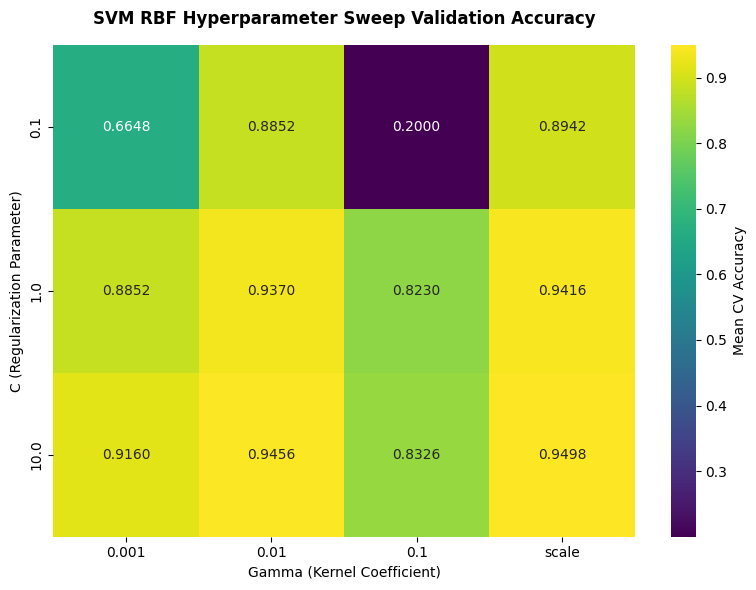

In [6]:
# Extract grid search results
results = pd.DataFrame(grid_search.cv_results_)
scores_matrix = results.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.4f', cmap='viridis', cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('SVM RBF Hyperparameter Sweep Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Gamma (Kernel Coefficient)', fontsize=10)
plt.ylabel('C (Regularization Parameter)', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Train and Evaluate Optimized RBF SVM
We train our final SVM classifier on the full 20,000 training set using the best hyperparameters discovered ($C=10, \gamma='scale'$).


In [7]:
# Train RBF SVM
best_C = best_params['C']
best_gamma = best_params['gamma']
svm_opt_model, t_svm_opt = train_rbf_svm(X_train, y_train, C=best_C, gamma=best_gamma)

# Evaluate optimized SVM
y_pred_svm, acc_svm, p_svm, r_svm, f1_svm, report_svm = evaluate_classifier(
    svm_opt_model, X_test, y_test
)

print("\nOptimized RBF SVM Metrics:")
print(f"  Accuracy:   {acc_svm*100:.2f}%")
print(f"  Macro F1:   {f1_svm*100:.2f}%")
print(f"  Train Time:  {t_svm_opt:.2f} seconds")

# Save model
save_model(svm_opt_model, "../models/best_svm_model.joblib")


2026-07-20 21:42:31,398 - INFO - Training RBF SVM (C=10, gamma=scale)...


2026-07-20 21:44:10,305 - INFO - RBF SVM trained in 98.90 seconds.


2026-07-20 21:44:17,352 - INFO - Evaluation - Acc: 0.9738, Precision: 0.9736, Recall: 0.9736, F1: 0.9735


2026-07-20 21:44:17,371 - INFO - Model saved to ../models/best_svm_model.joblib



Optimized RBF SVM Metrics:
  Accuracy:   97.38%
  Macro F1:   97.35%
  Train Time:  98.90 seconds


### Error Analysis: Confusion Matrix Heatmap
We generate predictions on the test set and plot the confusion matrix. This heatmap allows us to analyze common classification errors, such as confusions between '4' and '9' or '3' and '8'.


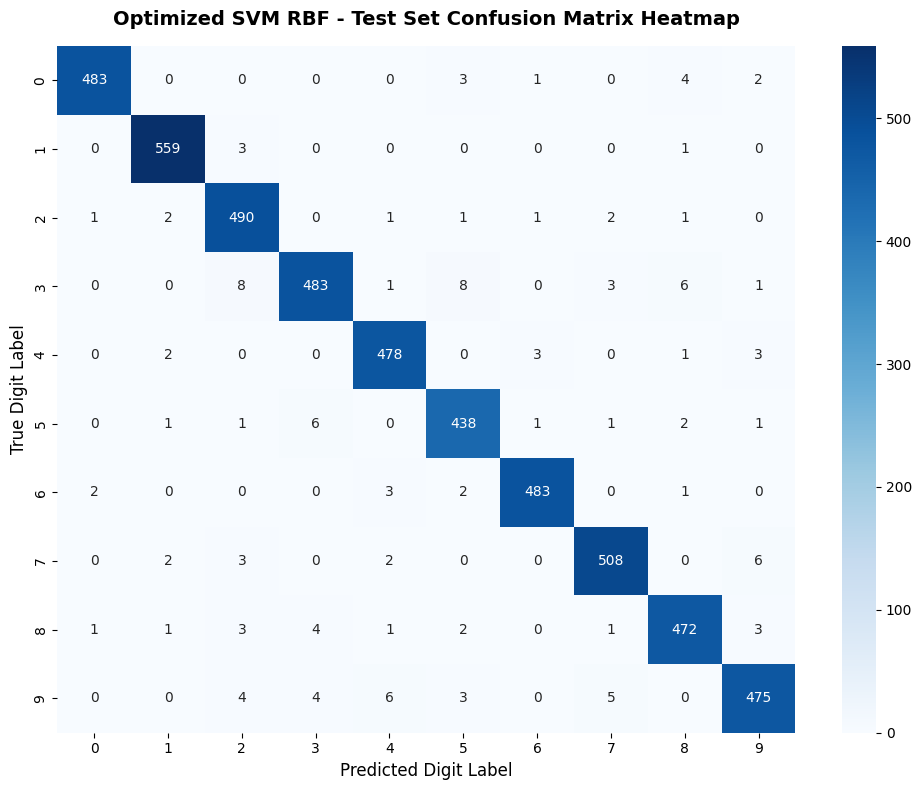

In [8]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)]
)
plt.title('Optimized SVM RBF - Test Set Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Digit Label', fontsize=12)
plt.xlabel('Predicted Digit Label', fontsize=12)
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=300)
plt.show()


## 6. Comparative Analysis: Random Forest Classifier
To evaluate the RBF SVM's accuracy and speed, we train and evaluate a `RandomForestClassifier` on the same data partitions.


In [9]:
# Train Random Forest
rf_model, t_rf_train = train_random_forest(X_train, y_train, n_estimators=100, random_state=42)

# Evaluate Random Forest
acc_rf, p_rf, r_rf, f1_rf, t_rf_pred = evaluate_random_forest(rf_model, X_test, y_test)

# Measure prediction time for SVM (on the 5,000 sample test set)
t_svm_pred_start = time.time()
_ = svm_opt_model.predict(X_test)
t_svm_pred = time.time() - t_svm_pred_start

print(f"\nRandom Forest Accuracy: {acc_rf*100:.2f}%")
print(f"Random Forest prediction time for {len(X_test)} samples: {t_rf_pred:.4f} seconds")
print(f"Optimized SVM prediction time for {len(X_test)} samples: {t_svm_pred:.4f} seconds")


2026-07-20 21:44:17,660 - INFO - Training RandomForestClassifier (n_estimators=100, max_depth=None)...


2026-07-20 21:44:18,652 - INFO - Random Forest trained in 0.99 seconds.


2026-07-20 21:44:18,653 - INFO - Evaluating RandomForestClassifier...


2026-07-20 21:44:18,679 - INFO - Random Forest - Acc: 0.9582, Precision: 0.9578, Recall: 0.9579, F1: 0.9578


2026-07-20 21:44:18,680 - INFO - Random Forest prediction speed: 0.0253 seconds for 5000 samples.



Random Forest Accuracy: 95.82%
Random Forest prediction time for 5000 samples: 0.0253 seconds
Optimized SVM prediction time for 5000 samples: 7.3730 seconds


### Benchmark Summary Table
We compare all models side-by-side.


In [10]:
comparison_data = {
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Training Time (s)", "Prediction Time (s)"],
    "Baseline Linear SVM": [acc_base, p_base, r_base, f1_base, t_baseline, t_baseline], # Approximated pred speed
    "Optimized RBF SVM": [acc_svm, p_svm, r_svm, f1_svm, t_svm_opt, t_svm_pred],
    "Random Forest": [acc_rf, p_rf, r_rf, f1_rf, t_rf_train, t_rf_pred]
}

comparison_df = pd.DataFrame(comparison_data)
from IPython.display import display, Markdown
display(Markdown(comparison_df.to_markdown(index=False)))


| Metric              |   Baseline Linear SVM |   Optimized RBF SVM |   Random Forest |
|:--------------------|----------------------:|--------------------:|----------------:|
| Accuracy            |              0.921    |            0.9738   |       0.9582    |
| Macro Precision     |              0.920291 |            0.973579 |       0.95783   |
| Macro Recall        |              0.919713 |            0.973603 |       0.957898  |
| Macro F1-Score      |              0.919677 |            0.973543 |       0.957813  |
| Training Time (s)   |             14.7064   |           98.9049   |       0.991639  |
| Prediction Time (s) |             14.7064   |            7.37299  |       0.0253482 |

## 7. Interactive Prediction Test (Demo)
We load a random image from the test set, render it visually using matplotlib, and run it through our prediction pipeline to verify live grading accuracy.


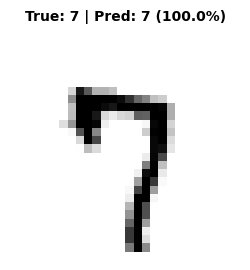

Class Probability Distribution:
  Digit 0:   0.0% | 
  Digit 1:   0.0% | 
  Digit 2:   0.0% | 
  Digit 3:   0.0% | 
  Digit 4:   0.0% | 
  Digit 5:   0.0% | 
  Digit 6:   0.0% | 
  Digit 7: 100.0% | ===================
  Digit 8:   0.0% | 
  Digit 9:   0.0% | 


In [11]:
# Pick a random sample index
idx = np.random.randint(0, len(X_test))
sample_features = X_test[idx]
true_label = y_test[idx]

# Predict
pred = svm_opt_model.predict([sample_features])[0]
probs = svm_opt_model.predict_proba([sample_features])[0]

# Plot image
plt.figure(figsize=(3, 3))
plt.imshow(sample_features.reshape(28, 28), cmap='binary')
plt.title(f"True: {true_label} | Pred: {pred} ({probs[pred]*100:.1f}%)", fontsize=10, fontweight='bold')
plt.axis('off')
plt.show()

# Print class distribution
print("Class Probability Distribution:")
for digit, prob in enumerate(probs):
    bar = "=" * int(prob * 20)
    print(f"  Digit {digit}: {prob*100:5.1f}% | {bar}")
